In [2]:
from pathlib import Path
import pandas as pd

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)


In [3]:
project_root = Path.cwd().resolve()
while not (project_root / "data").exists() and project_root != project_root.parent:
    project_root = project_root.parent

bronze_path = project_root / "data" / "bronze" / "bronze_DEP-departementale.csv"
silver_path = project_root / "data" / "silver" / "silver_DEP-departementale.csv"
silver_path.parent.mkdir(parents=True, exist_ok=True)

# Read bronze
df_bronze = pd.read_csv(
    bronze_path,
    sep=";",
    dtype=str,
    encoding="utf-8"
)

# Normalize column names
df_bronze.columns = [c.strip() for c in df_bronze.columns]

# Start silver
df_silver = df_bronze.copy()



In [4]:
# # Drop useless technical column
# if "Unnamed: 0" in df_silver.columns:
#     df_silver = df_silver.drop(columns=["Unnamed: 0"])


cols_keep = [
    "Code_departement",
    "Code_region",
    "annee",
    "indicateur",
    "unite_de_compte",
    "nombre",
    "taux_pour_mille",
    "insee_pop",
    "insee_pop_millesime",
    "insee_log",
    "insee_log_millesime",
    "extraction_source_url",
    "ingestion_timestamp",
    "source_file_name",
]

# Normalize column names
df_bronze.columns = [c.strip().replace("\ufeff", "") for c in df_bronze.columns]

print("Bronze columns:", df_bronze.columns.tolist())
print("Missing from cols_keep:", [c for c in cols_keep if c not in df_bronze.columns])

# Start silver
df_silver = df_bronze.copy()

# Drop useless technical column
if "Unnamed: 0" in df_silver.columns:
    df_silver = df_silver.drop(columns=["Unnamed: 0"])

existing_cols = [c for c in cols_keep if c in df_silver.columns]
print("Existing cols:", existing_cols)

df_silver = df_silver[existing_cols].copy()


existing_cols = [c for c in cols_keep if c in df_silver.columns]
df_silver = df_silver[existing_cols].copy()


# Helpers
def clean_string(series: pd.Series) -> pd.Series:
    return series.astype("string").str.strip()

def to_int_nullable(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce").astype("Int64")

def to_float_nullable(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype("string").str.replace(",", ".", regex=False),
        errors="coerce"
    ).astype("Float64")


# Cast strings
string_cols = [
    "Code_departement",
    "Code_region",
    "indicateur",
    "unite_de_compte",
    "extraction_source_url",
    "source_file_name",
]

for col in string_cols:
    if col in df_silver.columns:
        df_silver[col] = clean_string(df_silver[col])


# Preserve leading zeros on code fields
code_cols = [
    "Code_departement",
    "Code_region",
]

for col in code_cols:
    if col in df_silver.columns:
        df_silver[col] = clean_string(df_silver[col])


# Cast integers
int_cols = [
    "annee",
    "nombre",
    "insee_pop",
    "insee_pop_millesime",
    "insee_log",
    "insee_log_millesime",
]

for col in int_cols:
    if col in df_silver.columns:
        df_silver[col] = to_int_nullable(df_silver[col])


# Cast floats
float_cols = [
    "taux_pour_mille",
]

for col in float_cols:
    if col in df_silver.columns:
        df_silver[col] = to_float_nullable(df_silver[col])


# Cast timestamp
if "ingestion_timestamp" in df_silver.columns:
    df_silver["ingestion_timestamp"] = pd.to_datetime(
        df_silver["ingestion_timestamp"],
        errors="coerce"
    )


# Save silver
df_silver.to_csv(silver_path, sep=";", index=False, encoding="utf-8")

print(f"Wrote silver: {silver_path}")
print(f"Shape: {df_silver.shape}")
print("\nDtypes:")
print(df_silver.dtypes)
print("\nSample:")
display(df_silver.head())

Bronze columns: ['Code_departement', 'Code_region', 'annee', 'indicateur', 'unite_de_compte', 'nombre', 'taux_pour_mille', 'insee_pop', 'insee_pop_millesime', 'insee_log', 'insee_log_millesime', 'extraction_source_url', 'ingestion_timestamp', 'source_file_name']
Missing from cols_keep: []
Existing cols: ['Code_departement', 'Code_region', 'annee', 'indicateur', 'unite_de_compte', 'nombre', 'taux_pour_mille', 'insee_pop', 'insee_pop_millesime', 'insee_log', 'insee_log_millesime', 'extraction_source_url', 'ingestion_timestamp', 'source_file_name']
Wrote silver: /Users/zainfrayha/Desktop/electio-analytics-poc/data/silver/silver_DEP-departementale.csv
Shape: (180, 14)

Dtypes:
Code_departement         string[python]
Code_region              string[python]
annee                             Int64
indicateur               string[python]
unite_de_compte          string[python]
nombre                            Int64
taux_pour_mille                 Float64
insee_pop                         Int6

,Code_departement,Code_region,annee,indicateur,unite_de_compte,nombre,taux_pour_mille,insee_pop,insee_pop_millesime,insee_log,insee_log_millesime,extraction_source_url,ingestion_timestamp,source_file_name
0,69,84,2016,Homicides,Victime,23,0.012528,1835903,2016,904462,2016,https://www.data.gouv.fr/api/1/datasets/r/2b27...,2026-03-28 19:12:32.815146,DEP-departementale.csv
1,69,84,2017,Homicides,Victime,20,0.01085,1843319,2017,914980,2017,https://www.data.gouv.fr/api/1/datasets/r/2b27...,2026-03-28 19:12:32.815146,DEP-departementale.csv
2,69,84,2018,Homicides,Victime,19,0.010218,1859524,2018,926576,2018,https://www.data.gouv.fr/api/1/datasets/r/2b27...,2026-03-28 19:12:32.815146,DEP-departementale.csv
3,69,84,2019,Homicides,Victime,21,0.011196,1875747,2019,937544,2019,https://www.data.gouv.fr/api/1/datasets/r/2b27...,2026-03-28 19:12:32.815146,DEP-departementale.csv
4,69,84,2020,Homicides,Victime,21,0.01115,1883437,2020,949531,2020,https://www.data.gouv.fr/api/1/datasets/r/2b27...,2026-03-28 19:12:32.815146,DEP-departementale.csv


### Missingno pour df_silver ###



<Axes: >

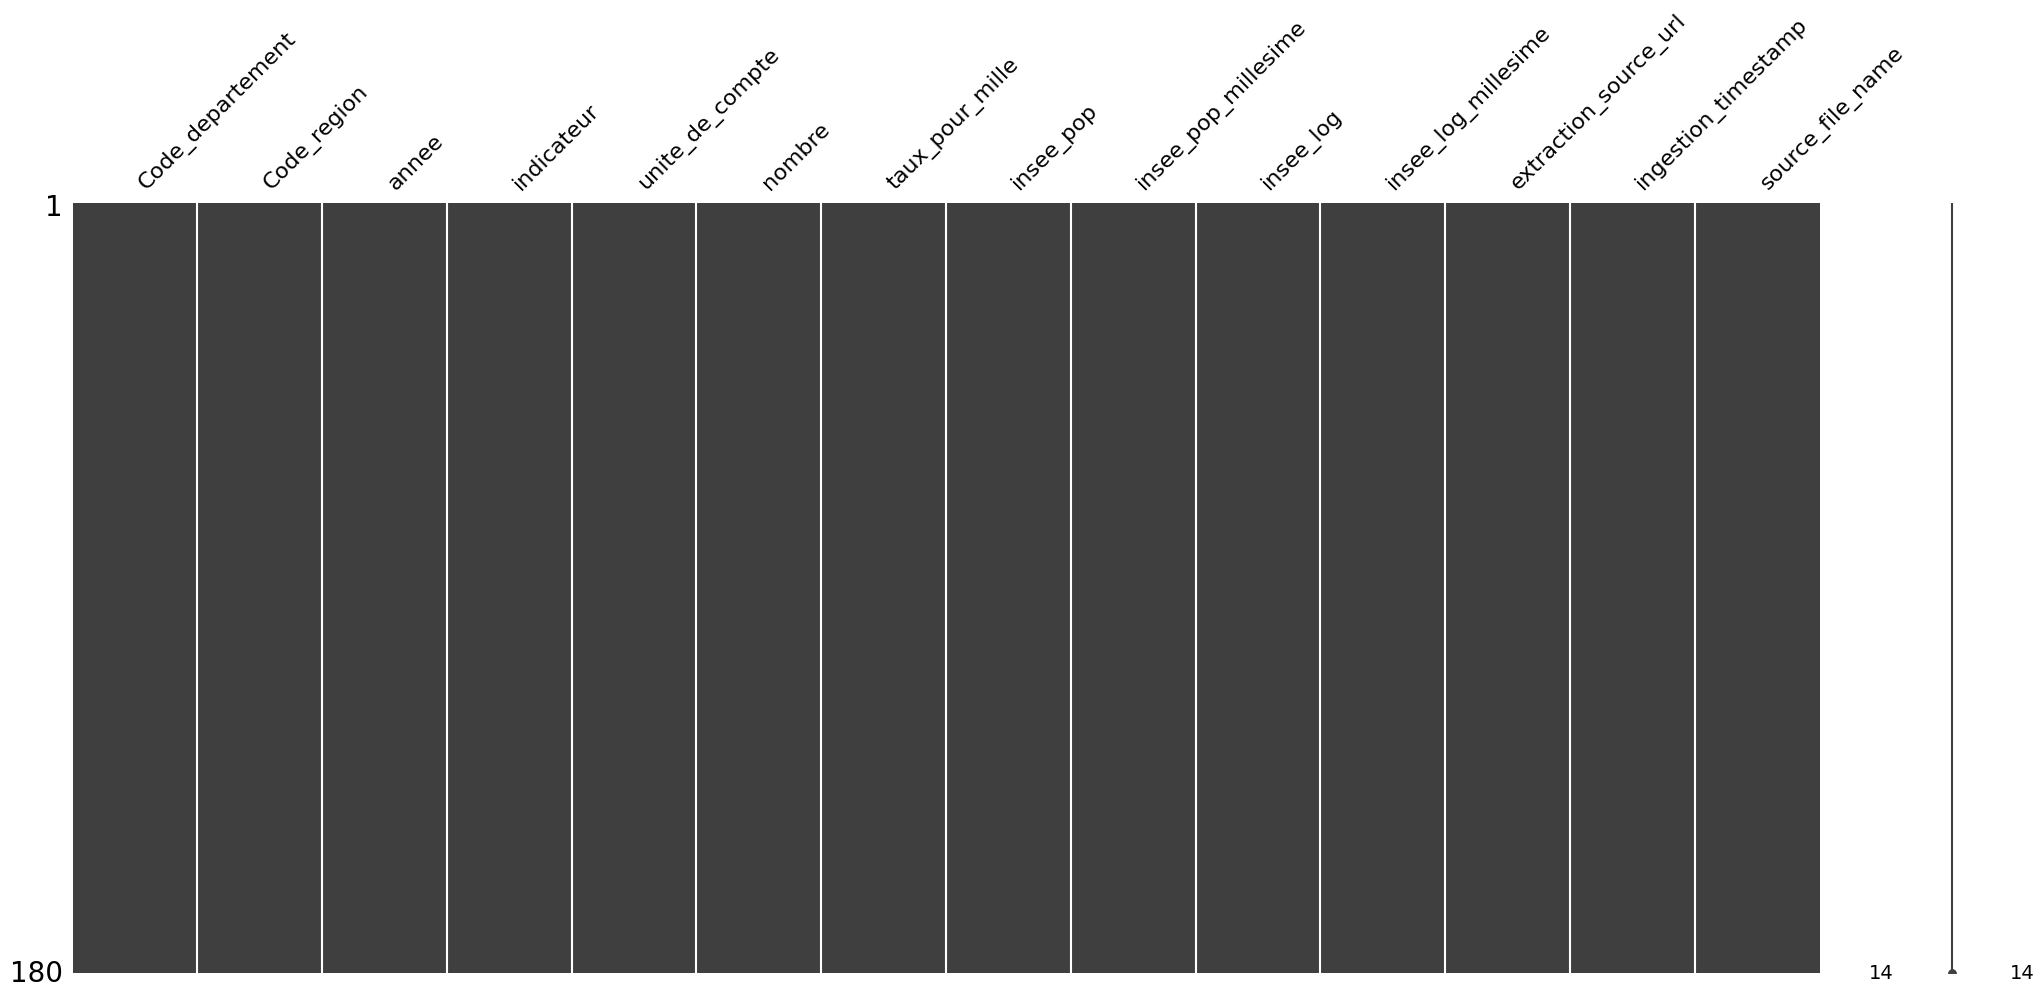

In [5]:
import missingno as msno

# Change 'df_bureau' to 'df_silver'
name = "df_silver"
print(f"### Missingno pour {name} ###\n")

# Use df_silver because that is what this script created
msno.matrix(df_silver)

In [6]:
unique_counts = df_silver.nunique(dropna=False).reset_index()
unique_counts.columns = ["column", "unique_count"]
display(unique_counts)


,column,unique_count
0,Code_departement,1
1,Code_region,1
2,annee,10
3,indicateur,18
4,unite_de_compte,5
5,nombre,170
6,taux_pour_mille,172
7,insee_pop,8
8,insee_pop_millesime,8
9,insee_log,7


In [7]:
print(f"Nombre de lignes : {df_silver.shape[0]}")
print(f"Nombre de colonnes : {df_silver.shape[1]}")


Nombre de lignes : 180
Nombre de colonnes : 14


In [8]:
print(f"### Statistiques descriptives pour {name} ###\n")
display(df_silver.describe(include='all'))

### Statistiques descriptives pour df_silver ###



,Code_departement,Code_region,annee,indicateur,unite_de_compte,nombre,taux_pour_mille,insee_pop,insee_pop_millesime,insee_log,insee_log_millesime,extraction_source_url,ingestion_timestamp,source_file_name
count,180,180,180.0,180,180,180.0,180.0,180.0,180.0,180.0,180.0,180,180,180
unique,1,1,<NA>,18,5,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,NaN,1
top,69,84,<NA>,Homicides,Victime,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,https://www.data.gouv.fr/api/1/datasets/r/2b27...,NaN,DEP-departementale.csv
freq,180,180,<NA>,10,60,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,180,NaN,180
mean,NaN,NaN,2020.5,NaN,NaN,7238.627778,4.095936,1884360.5,2020.2,950689.8,2019.9,NaN,2026-03-28 19:12:32.815145984,NaN
min,NaN,NaN,2016.0,NaN,NaN,0.0,0.0,1835903.0,2016.0,904462.0,2016.0,NaN,2026-03-28 19:12:32.815146,NaN
25%,NaN,NaN,2018.0,NaN,NaN,1798.5,0.947554,1859524.0,2018.0,926576.0,2018.0,NaN,2026-03-28 19:12:32.815145984,NaN
50%,NaN,NaN,2020.5,NaN,NaN,5168.5,2.744929,1888564.5,2020.5,956784.0,2020.5,NaN,2026-03-28 19:12:32.815145984,NaN
75%,NaN,NaN,2023.0,NaN,NaN,9510.0,6.13891,1914667.0,2023.0,977442.0,2022.0,NaN,2026-03-28 19:12:32.815145984,NaN
max,NaN,NaN,2025.0,NaN,NaN,33522.0,17.932008,1914667.0,2023.0,977442.0,2022.0,NaN,2026-03-28 19:12:32.815146,NaN


In [9]:
print(f"### Nombre de valeurs manquantes pour {name} ###\n")
display(df_silver.isnull().sum())

### Nombre de valeurs manquantes pour df_silver ###



Code_departement         0
Code_region              0
annee                    0
indicateur               0
unite_de_compte          0
nombre                   0
taux_pour_mille          0
insee_pop                0
insee_pop_millesime      0
insee_log                0
insee_log_millesime      0
extraction_source_url    0
ingestion_timestamp      0
source_file_name         0
dtype: int64

In [10]:
# Le pourcentage de valeur manquante de chaque colonnes
print(f"### Pourcentage de valeurs manquantes pour {name} ###\n")
display((df_silver.isnull().sum() / len(df_silver)) * 100)

### Pourcentage de valeurs manquantes pour df_silver ###



Code_departement         0.0
Code_region              0.0
annee                    0.0
indicateur               0.0
unite_de_compte          0.0
nombre                   0.0
taux_pour_mille          0.0
insee_pop                0.0
insee_pop_millesime      0.0
insee_log                0.0
insee_log_millesime      0.0
extraction_source_url    0.0
ingestion_timestamp      0.0
source_file_name         0.0
dtype: float64

In [13]:
print("Unique years in df_silver:")
display(sorted(df_silver['annee'].unique()))
display(sorted(df_silver['indicateur'].unique()))

Unique years in df_silver:


[2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

['Cambriolages de logement',
 'Destructions et dégradations volontaires',
 'Escroqueries et fraudes aux moyens de paiement',
 'Homicides',
 "Tentatives d'homicide",
 'Trafic de stupéfiants',
 'Usage de stupéfiants',
 'Usage de stupéfiants (AFD)',
 'Usage de stupéfiants (hors AFD)',
 'Violences physiques hors cadre familial',
 'Violences physiques intrafamiliales',
 'Violences sexuelles',
 'Vols avec armes',
 "Vols d'accessoires sur véhicules",
 'Vols dans les véhicules',
 'Vols de véhicule',
 'Vols sans violence contre des personnes',
 'Vols violents sans arme']